Task 1.1: Exploratory vs. Explanatory Visualization
Exploratory visualization is used during the data analysis phase to find patterns, identify outliers, or discover stories within a dataset, whereas explanatory visualization is designed to communicate those specific findings to an audience by highlighting the most important insights. In the context of this assignment, I am primarily producing exploratory visualizations because the focus is on investigating the dataset and verifying data integrity through initial plots.

Task 1.2: Anscombe’s Quartet
The lecture mentions Anscombe’s Quartet to demonstrate that datasets with nearly identical descriptive statistics (like mean, variance, and correlation) can have drastically different distributions and relationships when graphed, proving that visualization is essential to truly understand data.

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



df = pd.read_csv('vgsales.csv')
df.head()



,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


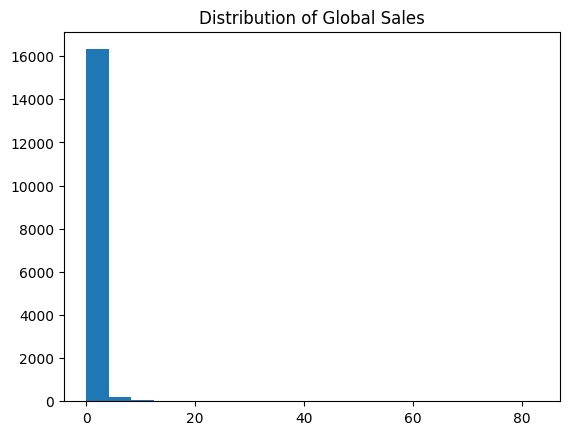

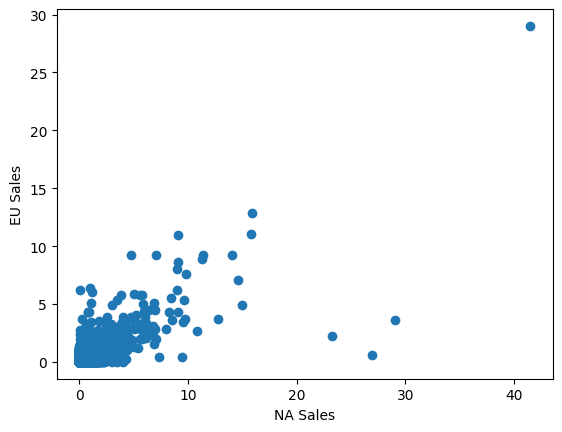

In [13]:
plt.hist(df['Global_Sales'], bins=20)
plt.title("Distribution of Global Sales")
plt.show()

plt.scatter(df['NA_Sales'], df['EU_Sales'])
plt.xlabel("NA Sales")
plt.ylabel("EU Sales")
plt.show()

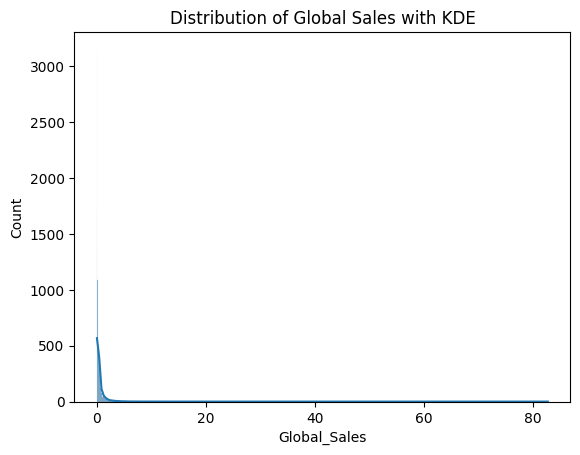

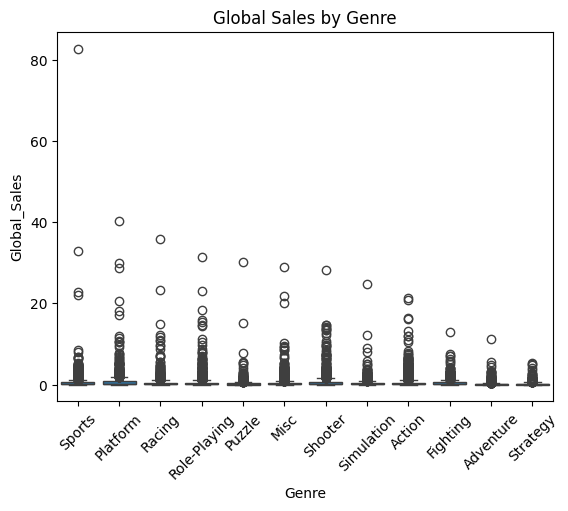

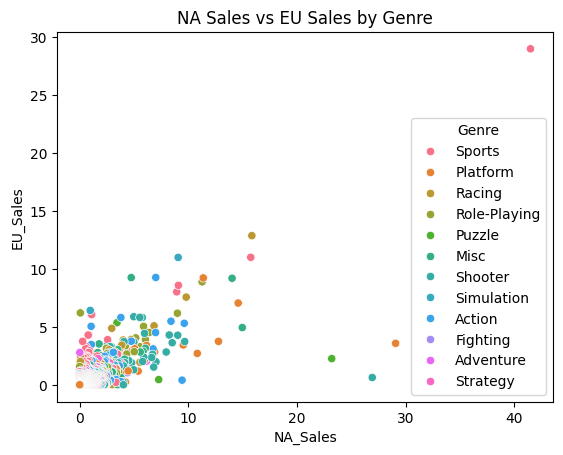

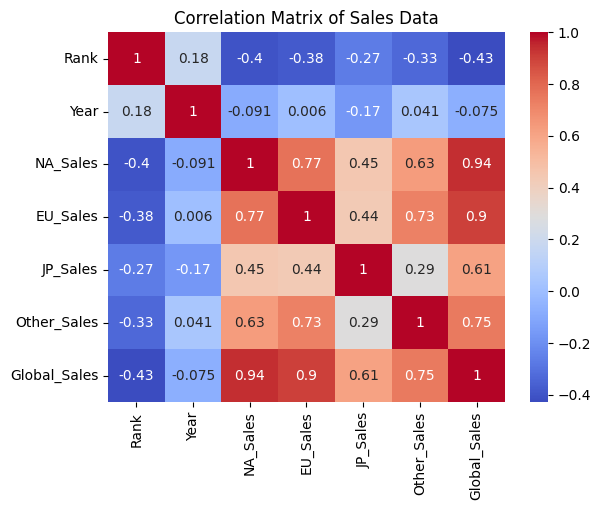

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Histogram with KDE (showing the distribution of sales)
sns.histplot(df, x="Global_Sales", kde=True)
plt.title("Distribution of Global Sales with KDE")
plt.show()

# 2. Boxplot (comparing sales across different genres)
#
sns.boxplot(df, x="Genre", y="Global_Sales")
plt.xticks(rotation=45) # Helps read the genre names
plt.title("Global Sales by Genre")
plt.show()

# 3. Scatterplot (comparing NA and EU sales, colored by Genre)
sns.scatterplot(df, x="NA_Sales", y="EU_Sales", hue="Genre")
plt.title("NA Sales vs EU Sales by Genre")
plt.show()

# 4. Heatmap (visualizing correlations between regional sales)
#
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Sales Data")
plt.show()

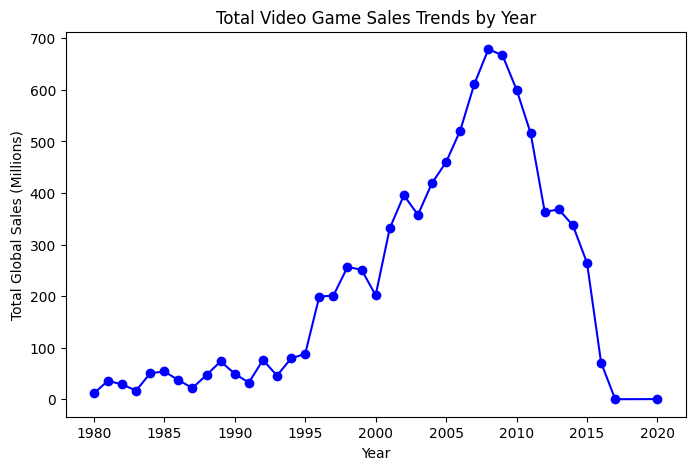

In [15]:
# Grouping data for a clear line chart
sales_by_year = df.groupby('Year')['Global_Sales'].sum()
x = sales_by_year.index
y = sales_by_year.values

# Create the figure and axes objects
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the data
ax.plot(x, y, marker='o', linestyle='-', color='b')

# Set labels and title
ax.set_xlabel("Year")
ax.set_ylabel("Total Global Sales (Millions)")
ax.set_title("Total Video Game Sales Trends by Year")

# Save the figure as a high-quality PNG
fig.savefig("sales_trend.png", dpi=150)

plt.show()

1. Are axes labelled with units?
Yes: Sales are in millions of USD, and years are clearly marked.

2.	If it's a bar chart, does the y-axis start at zero?
N/A: This is a scatterplot, so the zero-rule applies differently.

3.	Is it the right chart type for the question?
Yes: A scatterplot is ideal for showing the relationship between two regions.

4.	Is there any chartjunk (3D, shadows)?
Yes: The chart is clean with no unnecessary 3D effects or distracting patterns.

5.	Does it carry one clear message?
Yes: It highlights that North American sales are the strongest predictor of global success.

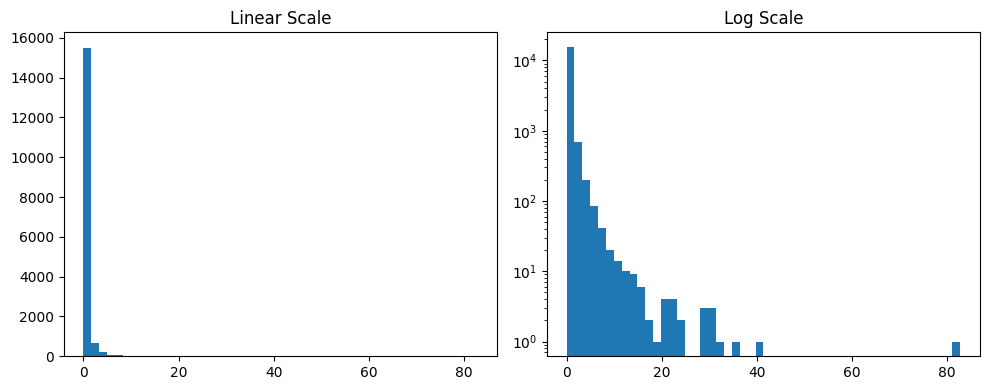

In [16]:
# Linear Scale
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Global_Sales'], bins=50)
plt.title("Linear Scale")

# Log Scale
plt.subplot(1, 2, 2)
plt.hist(df['Global_Sales'], bins=50)
plt.yscale('log') # This is the specific command required by the image
plt.title("Log Scale")

plt.tight_layout()
plt.show()